In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:
IMAGE_DIR = r"D:\FY_Project\Ai-CDD\data\raw\segmentation_sample\images"
MASK_DIR  = r"D:\FY_Project\Ai-CDD\data\raw\segmentation_sample\masks"

print("Image dir exists:", os.path.exists(IMAGE_DIR))
print("Mask dir exists:", os.path.exists(MASK_DIR))


Image dir exists: True
Mask dir exists: True


In [3]:
image_files = sorted(os.listdir(IMAGE_DIR))

sample_image_name = image_files[0]   # first image
sample_mask_name = sample_image_name.replace(".png", "_mask.png")

image_path = os.path.join(IMAGE_DIR, sample_image_name)
mask_path  = os.path.join(MASK_DIR, sample_mask_name)

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

print("Original image shape:", image.shape)
print("Original mask shape:", mask.shape)


Original image shape: (2843, 2536)
Original mask shape: (2843, 2536)


In [4]:
TARGET_SIZE = (256, 256)

# Resize
image_resized = cv2.resize(image, TARGET_SIZE)
mask_resized  = cv2.resize(mask, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)

# Normalize image to [0, 1]
image_norm = image_resized.astype(np.float32) / 255.0

# Binarize mask (0 or 1)
mask_bin = (mask_resized > 0).astype(np.uint8)

print("Processed image shape:", image_norm.shape)
print("Processed mask shape:", mask_bin.shape)
print("Image min/max:", image_norm.min(), image_norm.max())
print("Mask unique values:", np.unique(mask_bin))


Processed image shape: (256, 256)
Processed mask shape: (256, 256)
Image min/max: 0.0 1.0
Mask unique values: [0 1]


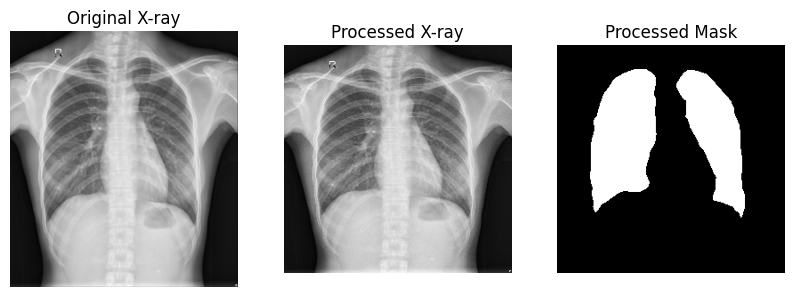

In [5]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.title("Original X-ray")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Processed X-ray")
plt.imshow(image_norm, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Processed Mask")
plt.imshow(mask_bin, cmap="gray")
plt.axis("off")

plt.show()
